# Dark-matter quantum-sensor response analysis

Forward + inverse analysis of the detector response, organised **by detector
material**. Each section runs the same pipeline (load Mathematica response
matrix → forward model `exposure · M @ eta` → recover the monotone non-negative
flux `x(v_min)`) for a different `material`:

- **TES (Al)** — Mermin dielectric, threshold 0.1 eV, fine binning `R10`.
- **MKID (TiN)** — analytic Lindhard dielectric, threshold 0.2 eV, fine binning `R9`.

The only thing that changes between detectors is `material` (`'Al'` / `'TiN'`):
the package maps it to the right Mathematica output tree (`output/TES` /
`output/MKID`) and exposure automatically.


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
from quantum_sensor import DarkMatterQuantumAnalysis, RunConfig

MASS_LABELS = {'1': '10 MeV', '2': '100 MeV', '3': '1 GeV'}
DETECTOR = {'Al': 'TES', 'TiN': 'MKID'}


def run_masses(material, q='0', nbins=5, eta='Halo', background='none',
               masses=('1', '2', '3'), solver='osqp'):
    """Run the forward+inverse analysis for several DM masses, side by side."""
    fig, axes = plt.subplots(1, len(masses), figsize=(6 * len(masses), 5), squeeze=False)
    for ax, mass in zip(axes[0], masses):
        a = DarkMatterQuantumAnalysis(
            RunConfig(material=material, q=q, mass=mass, nbins=nbins,
                      eta=eta, background=background))
        flux = a.optimize(solver=solver)
        a.plot(save=False, ax=ax)
        ax.set_title(f'{material} ({DETECTOR[material]}), $m_\\chi$ = {MASS_LABELS[mass]}',
                     fontsize=13)
        print(f'{material} q{q} M{mass} R{nbins}: {a.n_ebins} E-bins x '
              f'{a.n_vmin} v_min bins, peak flux {flux.max():.2e}')
    fig.suptitle(f'{material} ({DETECTOR[material]}), q{q}, R{nbins}, {eta}, bkg={background}',
                 fontsize=14)
    plt.tight_layout(); plt.show()


# TES (Al)

Aluminium detector, Mermin dielectric. Available matrices: heavy (`q0`) and
light (`q2`) mediators, 5-bin (`R5`) and 10-bin (`R10`) binnings.

## Heavy mediator (q0), 5 energy bins, Halo, signal only

Polishing not needed - no active set detected at optimal point
Al q0 M1 R5: 5 E-bins x 948 v_min bins, peak flux 9.54e-31
Polishing not needed - no active set detected at optimal point
Al q0 M2 R5: 5 E-bins x 985 v_min bins, peak flux 9.00e-32
Polishing not needed - no active set detected at optimal point
Al q0 M3 R5: 5 E-bins x 996 v_min bins, peak flux 9.04e-33


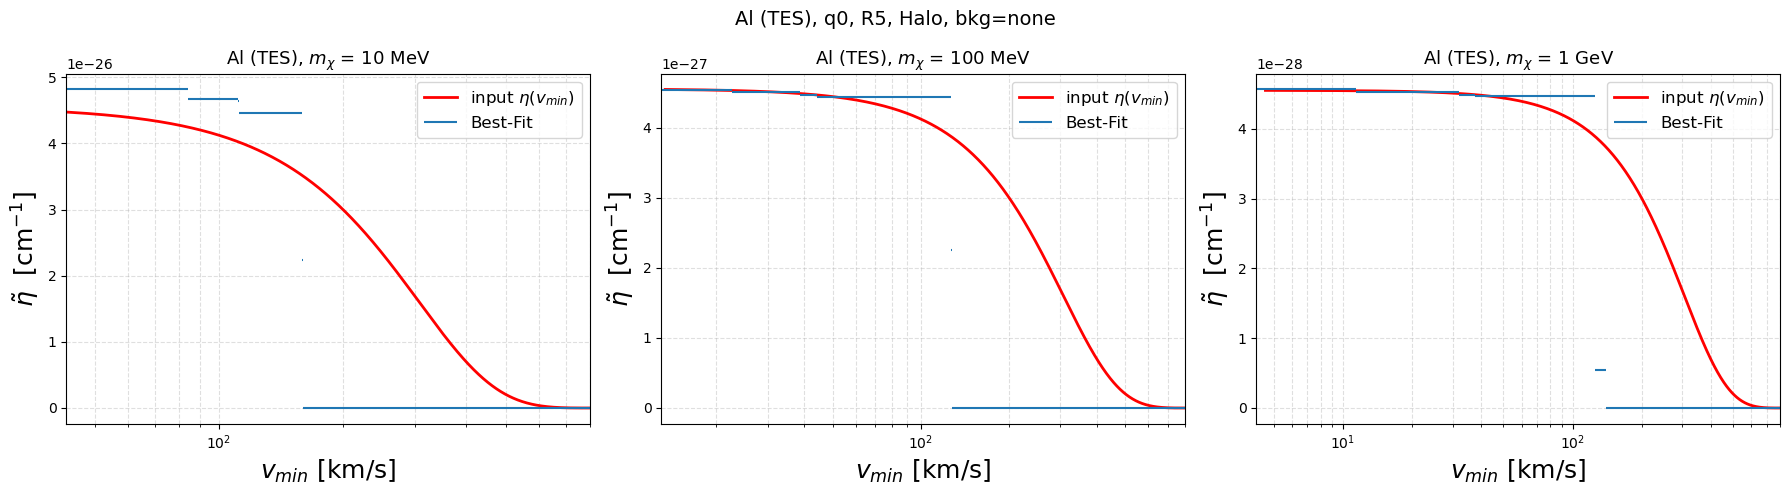

In [4]:
run_masses('Al', q='0', nbins=5)

## Light mediator (q2), 5 energy bins

Polishing not needed - no active set detected at optimal point
Al q2 M1 R5: 5 E-bins x 948 v_min bins, peak flux 8.65e-31
Al q2 M2 R5: 5 E-bins x 985 v_min bins, peak flux 8.98e-32
Al q2 M3 R5: 5 E-bins x 996 v_min bins, peak flux 8.98e-33


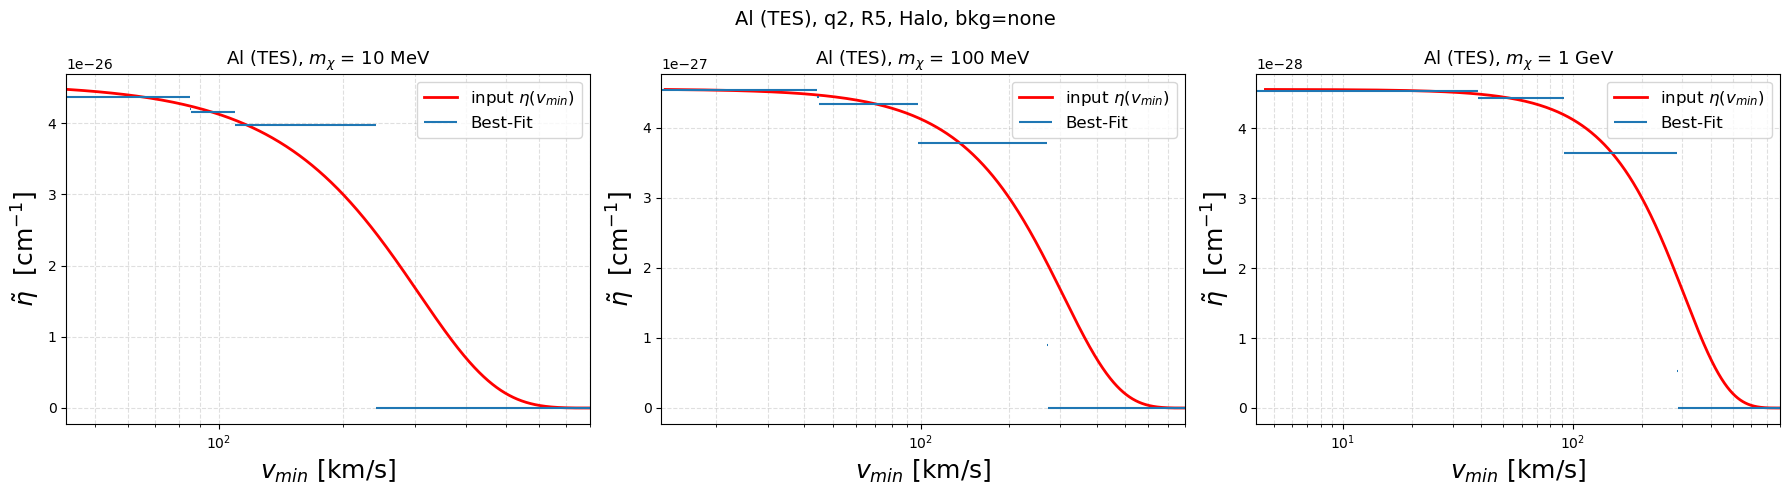

In [5]:
run_masses('Al', q='2', nbins=5)

## Finer energy binning (R10)

Al q0 M1 R10: 10 E-bins x 948 v_min bins, peak flux 9.64e-31
Al q0 M2 R10: 10 E-bins x 985 v_min bins, peak flux 8.99e-32
Polishing not needed - no active set detected at optimal point
Al q0 M3 R10: 10 E-bins x 996 v_min bins, peak flux 9.03e-33


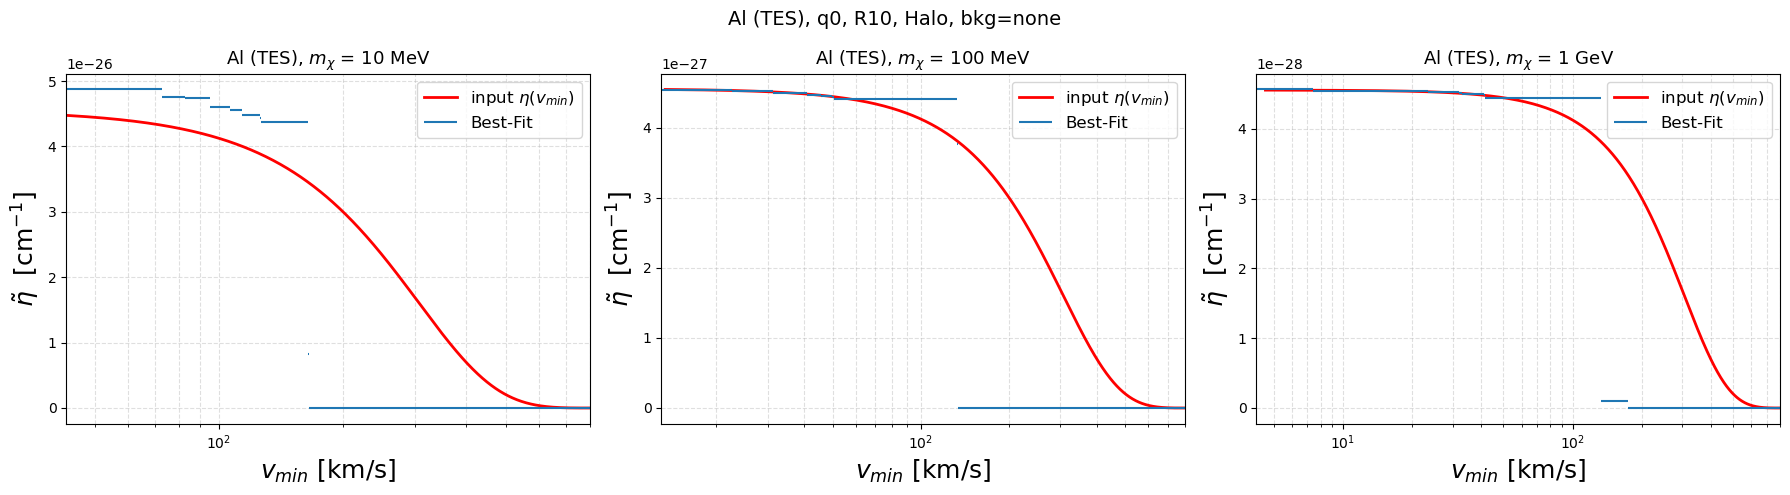

In [6]:
run_masses('Al', q='0', nbins=10)

Polishing not needed - no active set detected at optimal point
Al q2 M1 R10: 10 E-bins x 948 v_min bins, peak flux 8.75e-31
Al q2 M2 R10: 10 E-bins x 985 v_min bins, peak flux 8.99e-32
Al q2 M3 R10: 10 E-bins x 996 v_min bins, peak flux 9.03e-33


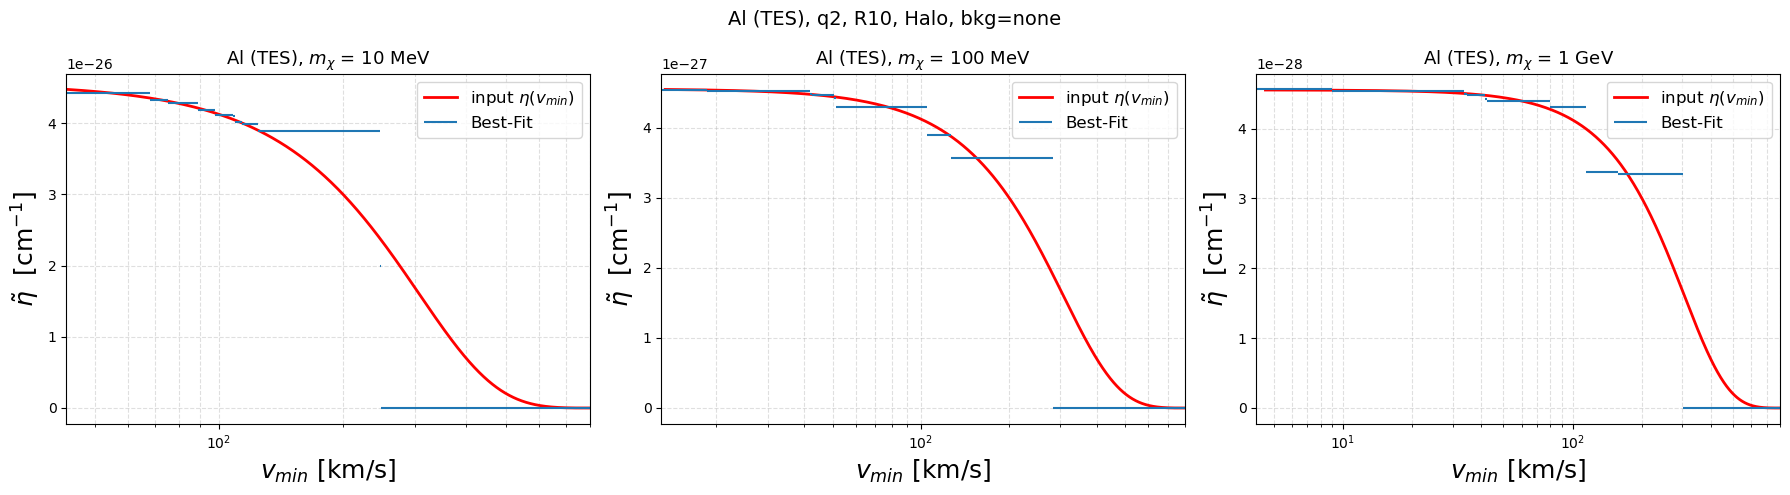

In [7]:
run_masses('Al', q='2', nbins=10)

## With a background scenario

Polishing not needed - no active set detected at optimal point
signal     : [0.25399263 0.49316709 0.73310345 0.96663229 1.1931241 ]
background : [5.03778479 4.9669399  4.89749784 4.82943082 4.76271162]


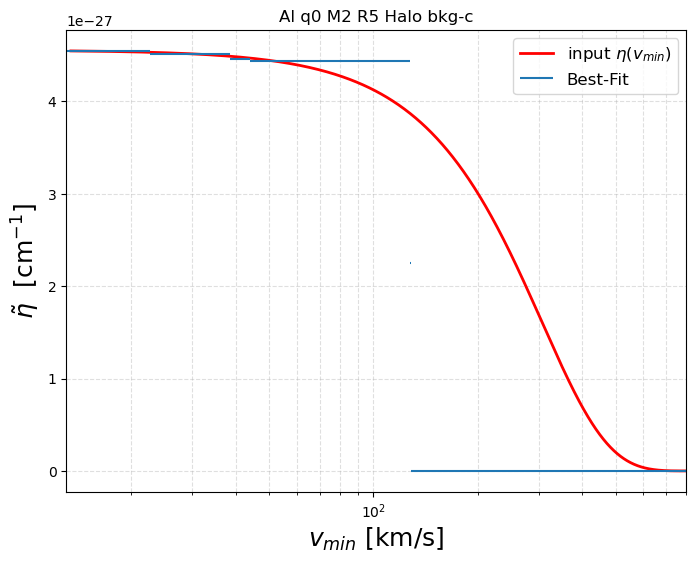

In [8]:
a = DarkMatterQuantumAnalysis(
    RunConfig(material='Al', q='0', mass='2', nbins=5, eta='Halo', background='c'))
a.optimize(solver='osqp')
print('signal     :', a.signal)
print('background :', a.background)
a.plot(save=False); plt.show()

# MKID (TiN)

Titanium-nitride detector, analytic Lindhard dielectric. The detection
**threshold is 0.2 eV**, so the energy bins start at 0.2 eV and the fine
binning is **`R9`** (0.2–1.1 eV in 0.1 eV steps), not `R10`.

Currently generated: heavy mediator (`q0`), masses M1–M3, `R5` and `R9`. The
light mediator (`q2`) requires generating the MKID `q2` matrices first
(`08_response_functions.wl … q2` → `10_response_matrix.wl` → `12_eta.wl`).

## Heavy mediator (q0), 5 energy bins, Halo, signal only

Polishing not needed - no active set detected at optimal point
TiN q0 M1 R5: 5 E-bins x 931 v_min bins, peak flux 8.58e-31
Polishing not needed - no active set detected at optimal point
TiN q0 M2 R5: 5 E-bins x 980 v_min bins, peak flux 9.01e-32
Polishing not needed - no active set detected at optimal point
TiN q0 M3 R5: 5 E-bins x 995 v_min bins, peak flux 9.02e-33


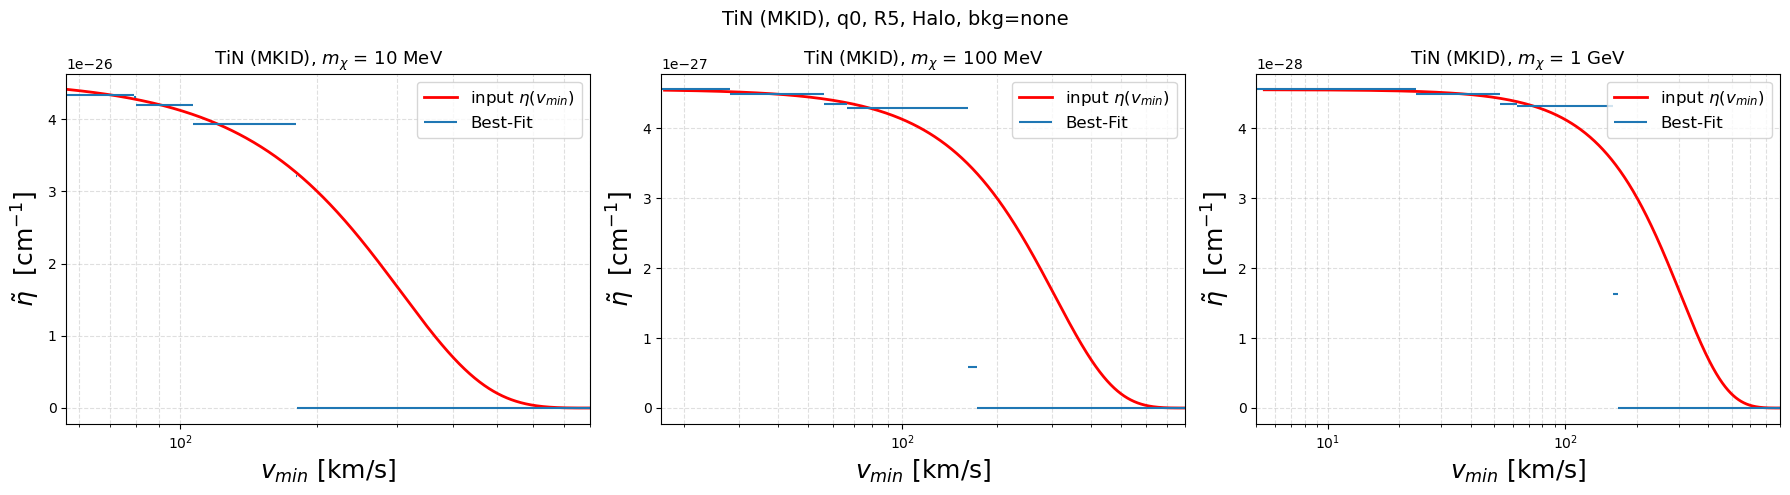

In [2]:
run_masses('TiN', q='0', nbins=5)

## Finer energy binning (R9)

TiN q0 M1 R9: 9 E-bins x 931 v_min bins, peak flux 8.59e-31
TiN q0 M2 R9: 9 E-bins x 980 v_min bins, peak flux 8.99e-32
TiN q0 M3 R9: 9 E-bins x 995 v_min bins, peak flux 9.00e-33


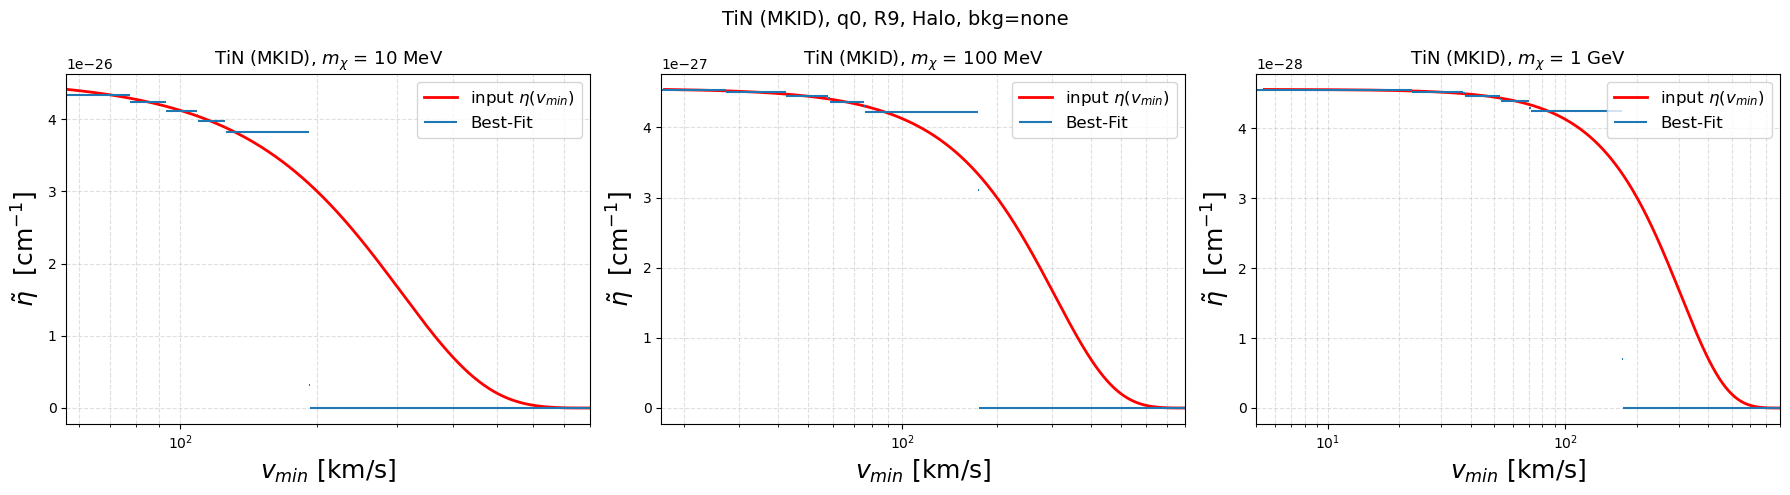

In [3]:
run_masses('TiN', q='0', nbins=9)